In [1]:
import os
import random
import time
import torch
import numpy as np
import matplotlib.pyplot as plt

from transformers import AutoTokenizer, AutoModel
from datasets import load_dataset
from sklearn.decomposition import PCA
from collections import defaultdict
from scipy.stats import wasserstein_distance  # for optional Wasserstein

###############################################################################
# Arguments
###############################################################################
args = {
    "models": [
        "nlpaueb/sec-bert-base",
        "bert-base-uncased"
    ],
    "datasets": [
        {
            "name": "yelp_review_full",
            "config": None,
            "split": "train",
            "text_column": "text"
        },
        {
            "name": "wikitext",
            "config": "wikitext-2-raw-v1",
            "split": "train",
            "text_column": "text"
        },
        {
            "name": "ag_news",
            "config": None,
            "split": "train",
            "text_column": "text"
        },
    ],
    "distribution_measures": ["mmd", "kl", "js", "hellinger", "bhattacharyya", "wasserstein"],  

    "max_texts": 1000,
    "batch_size": 64,
    "drift_strengths": [0.0, 0.25, 0.5, 0.75, 1.0],
    "pca_components": 2,
    "hist_bins": 30,  # for histogram-based measures
    "output_dir": "data-analysis/data",

    "num_seeds": 1,             # Number of random seeds
    "use_adaptive_gamma": True, # Whether to select gamma adaptively for MMD
    "num_permutations": 100,    # Number of permutations for the distribution test
    "alpha": 0.05               # Significance level for drift detection
}
os.makedirs(args["output_dir"], exist_ok=True)

###############################################################################
# Utility Functions
###############################################################################
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def batch_generator(data, batch_size=32):
    for i in range(0, len(data), batch_size):
        yield data[i : i + batch_size]

def extract_cls_embeddings(model, tokenizer, texts, device):
    encodings = tokenizer(
        texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=128
    )
    input_ids = encodings["input_ids"].to(device)
    attention_mask = encodings["attention_mask"].to(device)
    with torch.no_grad():
        outputs = model(input_ids, attention_mask=attention_mask)
        cls_embeddings = outputs.last_hidden_state[:, 0, :]
    return cls_embeddings.cpu().numpy()

def introduce_gradual_drift(text_list, fraction_shuffle=0.5):
    """
    Simple 'drift' function that shuffles a fraction of words in each text.
    """
    new_texts = []
    for txt in text_list:
        words = txt.split()
        if len(words) < 2:
            new_texts.append(txt)
            continue
        k = int(len(words) * fraction_shuffle)
        if k < 1:
            new_texts.append(txt)
            continue
        indices = list(range(len(words)))
        random.shuffle(indices)
        shuffle_indices = indices[:k]
        to_shuffle = [words[i] for i in shuffle_indices]
        random.shuffle(to_shuffle)
        for i, idx in enumerate(shuffle_indices):
            words[idx] = to_shuffle[i]
        new_texts.append(" ".join(words))
    return new_texts

###############################################################################
# 2D Histogram-Based Distances (KL, JS, Hellinger, Bhattacharyya)
###############################################################################
def safe_prob(p, eps=1e-12):
    return np.maximum(p, eps)

def kl_divergence(p, q, eps=1e-12):
    p_ = safe_prob(p, eps=eps)
    q_ = safe_prob(q, eps=eps)
    return np.sum(p_ * np.log(p_ / q_))

def js_divergence(p, q, eps=1e-12):
    p_ = safe_prob(p, eps=eps)
    q_ = safe_prob(q, eps=eps)
    m_ = 0.5 * (p_ + q_)
    return 0.5 * kl_divergence(p_, m_, eps) + 0.5 * kl_divergence(q_, m_, eps)

def hellinger_distance(p, q, eps=1e-12):
    p_ = np.sqrt(safe_prob(p, eps=eps))
    q_ = np.sqrt(safe_prob(q, eps=eps))
    return np.sqrt(np.sum((p_ - q_)**2) / 2.0)

def bhattacharyya_distance(p, q, eps=1e-12):
    bc = np.sum(np.sqrt(safe_prob(p, eps=eps) * safe_prob(q, eps=eps)))
    return -np.log(bc + 1e-12)

def build_2d_hist(embs_2d, bins=30):
    hist, xedges, yedges = np.histogram2d(
        embs_2d[:, 0],
        embs_2d[:, 1],
        bins=bins,
        density=False
    )
    hist = hist / hist.sum()
    return hist, xedges, yedges

def compute_2d_hist_distance(baseline_embs_2d, new_embs_2d,
                             measure="js",
                             bins=30,
                             eps=1e-12):
    """
    1) Build 2D hist for baseline
    2) Build 2D hist for new data with same bin edges
    3) Compute specified measure
    """
    hist_p, xedges, yedges = build_2d_hist(baseline_embs_2d, bins=bins)
    hist_q_raw, _, _ = np.histogram2d(
        new_embs_2d[:, 0],
        new_embs_2d[:, 1],
        bins=[xedges, yedges],
        density=False
    )
    hist_q = hist_q_raw / hist_q_raw.sum()

    p = hist_p.flatten()
    q = hist_q.flatten()

    if measure == "kl":
        return kl_divergence(p, q, eps=eps)
    elif measure == "js":
        return js_divergence(p, q, eps=eps)
    elif measure == "hellinger":
        return hellinger_distance(p, q, eps=eps)
    elif measure == "bhattacharyya":
        return bhattacharyya_distance(p, q, eps=eps)
    else:
        raise ValueError(f"Unknown histogram measure: {measure}")

###############################################################################
# MMD Computation (already done)
###############################################################################
def rbf_kernel(x, y, gamma=1.0):
    x2 = np.sum(x**2, axis=1)[:, None]
    y2 = np.sum(y**2, axis=1)[None, :]
    dist2 = x2 + y2 - 2 * np.dot(x, y.T)
    return np.exp(-gamma * dist2)

def compute_mmd(baseline_embs, new_embs, gamma=0.5):
    X = baseline_embs
    Y = new_embs
    XX = rbf_kernel(X, X, gamma=gamma)
    YY = rbf_kernel(Y, Y, gamma=gamma)
    XY = rbf_kernel(X, Y, gamma=gamma)
    m = len(X)
    n = len(Y)
    mmd2 = XX.sum() / (m**2) + YY.sum() / (n**2) - 2.0 * XY.sum() / (m*n)
    return np.sqrt(mmd2)

def auto_select_gamma(embs):
    """
    Simple heuristic: gamma = 1/(2*median_of_pairwise_distance^2).
    """
    sample = embs
    if len(embs) > 500:
        sample = embs[np.random.choice(len(embs), 500, replace=False)]
    dists = []
    for i in range(len(sample)-1):
        dist2 = np.sum((sample[i] - sample[i+1:])**2, axis=1)
        dists.append(dist2)
    dists = np.concatenate(dists)
    median_dist2 = np.median(dists)
    if median_dist2 <= 0.0:
        median_dist2 = 1e-6
    return 1.0 / (2.0 * median_dist2)

###############################################################################
# Wasserstein (Optional)
###############################################################################
def compute_wasserstein_1D_per_dim(baseline_embs, new_embs):
    """
    For simplicity, sum of 1D Wasserstein distances across all dimensions.
    """
    from scipy.stats import wasserstein_distance
    d = baseline_embs.shape[1]
    w_sum = 0.0
    for i in range(d):
        w_sum += wasserstein_distance(baseline_embs[:, i], new_embs[:, i])
    return w_sum

###############################################################################
# General Compute Distance
###############################################################################
def compute_distance(baseline_embs, new_embs, measure="mmd", gamma_val=0.5, pca_2d=None, bins=30):
    """
    Based on 'measure', compute the distribution distance.
    For histogram-based measures, we use pca_2d to transform embeddings to Nx2.
    """
    if measure == "mmd":
        return compute_mmd(baseline_embs, new_embs, gamma=gamma_val)
    elif measure in ["kl", "js", "hellinger", "bhattacharyya"]:
        # histogram-based measure in 2D
        if pca_2d is None:
            raise ValueError("PCA model needed for histogram-based measure.")
        base_2d = pca_2d.transform(baseline_embs)
        new_2d  = pca_2d.transform(new_embs)
        return compute_2d_hist_distance(base_2d, new_2d, measure=measure, bins=bins)
    elif measure == "wasserstein":
        return compute_wasserstein_1D_per_dim(baseline_embs, new_embs)
    else:
        raise ValueError(f"Unknown measure: {measure}")

###############################################################################
# Permutation Test for Any Distribution Measure
###############################################################################
def permutation_test_distribution(baseline_embs,
                                  new_embs,
                                  measure="mmd",
                                  gamma_val=0.5,
                                  pca_2d=None,
                                  bins=30,
                                  num_permutations=100):
    """
    General permutation test for a chosen measure.
    """
    actual_dist = compute_distance(baseline_embs, new_embs,
                                   measure=measure,
                                   gamma_val=gamma_val,
                                   pca_2d=pca_2d,
                                   bins=bins)

    combined = np.concatenate([baseline_embs, new_embs], axis=0)
    n_baseline = len(baseline_embs)
    n_combined = len(combined)

    perm_dists = []
    for _ in range(num_permutations):
        perm_indices = np.random.permutation(n_combined)
        Xperm = combined[perm_indices[:n_baseline]]
        Yperm = combined[perm_indices[n_baseline:]]
        dist_val = compute_distance(Xperm, Yperm,
                                    measure=measure,
                                    gamma_val=gamma_val,
                                    pca_2d=pca_2d,
                                    bins=bins)
        perm_dists.append(dist_val)

    perm_dists = np.array(perm_dists)
    p_val = np.mean(perm_dists >= actual_dist)
    return actual_dist, perm_dists, p_val

###############################################################################
# Main function for a single seed
###############################################################################
def run_experiment_single_seed(seed, args):
    set_seed(seed)

    if torch.backends.mps.is_available():
        device = torch.device("mps")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
    else:
        device = torch.device("cpu")
    print(f"[Seed={seed}] Using device: {device}")

    results = defaultdict(list)

    for dataset_info in args["datasets"]:
        dataset_name  = dataset_info["name"]
        dataset_config = dataset_info["config"]
        dataset_split = dataset_info["split"]
        text_col      = dataset_info["text_column"]

        print(f"[Seed={seed}] === Loading dataset: {dataset_name} ===")
        ds = load_dataset(dataset_name, dataset_config, split=dataset_split)
        texts = list(ds[text_col])
        random.shuffle(texts)
        if args["max_texts"] > 0 and len(texts) > args["max_texts"]:
            texts = texts[: args["max_texts"]]

        half_point = len(texts) // 2
        baseline_texts = texts[:half_point]
        drift_texts    = texts[half_point:]

        for model_name in args["models"]:
            print(f"[Seed={seed}] --- Using Model: {model_name} ---")
            tokenizer = AutoTokenizer.from_pretrained(model_name)
            model = AutoModel.from_pretrained(model_name)
            model.to(device)
            model.eval()

            # Precompute baseline embeddings
            baseline_embs_list = []
            for b in batch_generator(baseline_texts, args["batch_size"]):
                emb_b = extract_cls_embeddings(model, tokenizer, b, device)
                baseline_embs_list.append(emb_b)
            baseline_embs = np.concatenate(baseline_embs_list, axis=0)

            # Fit PCA for histogram-based measures (KL, JS, etc.)
            pca_model = PCA(n_components=args["pca_components"])
            pca_model.fit(baseline_embs)

            # If MMD with adaptive gamma
            if args["use_adaptive_gamma"]:
                gamma_val = auto_select_gamma(baseline_embs)
            else:
                gamma_val = 0.5

            for measure in args["distribution_measures"]:
                print(f"    -> Running measure: {measure}")

                for drift_strength in args["drift_strengths"]:
                    start_time = time.time()

                    drifted_texts = introduce_gradual_drift(drift_texts,
                                                            fraction_shuffle=drift_strength)
                    new_embs_list = []
                    for b in batch_generator(drifted_texts, args["batch_size"]):
                        emb_b = extract_cls_embeddings(model, tokenizer, b, device)
                        new_embs_list.append(emb_b)
                    new_embs = np.concatenate(new_embs_list, axis=0)

                    # Permutation test for chosen measure
                    actual_dist, perm_dists, p_val = permutation_test_distribution(
                        baseline_embs,
                        new_embs,
                        measure=measure,
                        gamma_val=gamma_val,
                        pca_2d=pca_model,
                        bins=args["hist_bins"],
                        num_permutations=args["num_permutations"]
                    )

                    drift_detected = bool(p_val < args["alpha"])

                    end_time = time.time()
                    time_taken = end_time - start_time

                    key = (dataset_name, model_name, measure, drift_strength)
                    results[key].append({
                        "distance_val": actual_dist,
                        "perm_dists": perm_dists,
                        "p_val": p_val,
                        "drift_detected": drift_detected,
                        "time_taken": time_taken,
                        "seed": seed
                    })

    return results

###############################################################################
# Multiple Seeds
###############################################################################
def collect_data_multiple_seeds(args):
    all_results = defaultdict(list)
    for seed in range(args["num_seeds"]):
        seed_results = run_experiment_single_seed(seed, args)
        for k, list_of_records in seed_results.items():
            all_results[k].extend(list_of_records)
    print("Data collection (all seeds) done!")
    return all_results

###############################################################################
# Visualization
###############################################################################
def plot_results(all_results, alpha=0.05):
    """
    Plots distance measure and p-value vs. drift strength for each (dataset, model, measure).
    """
    from collections import defaultdict

    # Group by (dataset, model, measure)
    grouped = defaultdict(list)
    for (dataset_name, model_name, measure, drift_strength), records in all_results.items():
        r = records[0]  # if multiple seeds, could average
        grouped[(dataset_name, model_name, measure)].append(
            (drift_strength, r["distance_val"], r["p_val"], r["drift_detected"])
        )

    for (dataset_name, model_name, measure), vals in grouped.items():
        vals.sort(key=lambda x: x[0])  # sort by drift_strength
        drift_strengths = [v[0] for v in vals]
        dist_vals       = [v[1] for v in vals]
        p_values        = [v[2] for v in vals]
        drift_flags     = [v[3] for v in vals]

        plt.figure(figsize=(10,4))
        # Left: Distance vs. drift_strength
        plt.subplot(1,2,1)
        plt.plot(drift_strengths, dist_vals, marker='o', label=f"{measure}")
        # Mark points where drift is detected
        for ds, dval, detected in zip(drift_strengths, dist_vals, drift_flags):
            if detected:
                plt.scatter(ds, dval, color='red', s=80, marker='x', zorder=5)
        plt.title(f"{measure.upper()} vs. Drift Strength\n{dataset_name} | {model_name}")
        plt.xlabel("Drift Strength")
        plt.ylabel(f"{measure.upper()}")
        plt.grid(True)
        plt.legend()

        # Right: p-value vs. drift_strength
        plt.subplot(1,2,2)
        plt.plot(drift_strengths, p_values, marker='o', label="p-value")
        plt.axhline(y=alpha, color='r', linestyle='--', label=f"alpha={alpha}")
        plt.title("p-value vs. Drift Strength")
        plt.xlabel("Drift Strength")
        plt.ylabel("p-value")
        plt.ylim([0,1])
        plt.grid(True)
        plt.legend()

        plt.tight_layout()
        plt.show()

def plot_permutation_distribution(all_results, dataset, model, measure, drift_strength):
    """
    Plots the histogram of permuted distances for a specific scenario.
    """
    key = (dataset, model, measure, drift_strength)
    if key not in all_results:
        print("No results found for that key:", key)
        return

    record = all_results[key][0]  # if multiple seeds, pick the first
    perm_dists = record["perm_dists"]
    actual_dist = record["distance_val"]
    p_val = record["p_val"]

    plt.figure(figsize=(7,5))
    plt.hist(perm_dists, bins=20, alpha=0.7, color='blue', edgecolor='black')
    plt.axvline(x=actual_dist, color='red', linewidth=2,
                label=f"Actual {measure}={actual_dist:.4f}")
    plt.title(f"Permutation Distribution for {measure.upper()}\n"
              f"{dataset} | {model} | drift={drift_strength}\np-value={p_val:.4f}")
    plt.xlabel(f"{measure.upper()}")
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()

###############################################################################
# Execute
###############################################################################
all_results = collect_data_multiple_seeds(args)

# -------------------------------------------------------------------
# (1) Print summary
# -------------------------------------------------------------------
for k, records in all_results.items():
    dataset_name, model_name, measure, drift_strength = k
    for r in records:
        print(
            f"\n[dataset={dataset_name}, model={model_name}, measure={measure}, drift={drift_strength}]"
            f"\n  Seed={r['seed']} | Dist={r['distance_val']:.4f} "
            f"| p-value={r['p_val']:.4f} "
            f"| Drift={r['drift_detected']} "
            f"| Time={r['time_taken']:.2f}s"
        )

# -------------------------------------------------------------------
# (2) Compute False Positive Rate (FPR) for each measure
# -------------------------------------------------------------------
# FPR means "detecting drift" when drift_strength = 0.0.
measure_counts = defaultdict(lambda: {"detected": 0, "total": 0})

for (dataset_name, model_name, measure, drift_strength), records in all_results.items():
    if drift_strength == 0.0:
        # This is the "no drift" case
        for r in records:
            measure_counts[measure]["total"] += 1
            if r["drift_detected"]:
                measure_counts[measure]["detected"] += 1

print("\n=== False Positive Rates (FPR) ===")
for measure in args["distribution_measures"]:
    c = measure_counts[measure]
    if c["total"] > 0:
        fpr = c["detected"] / c["total"]
    else:
        fpr = 0.0
    print(f"Measure={measure:<12} FPR={fpr:.3f}")


/Users/jasper.bruin/Documents/driftwatch/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[Seed=0] Using device: mps
[Seed=0] === Loading dataset: yelp_review_full ===
[Seed=0] --- Using Model: nlpaueb/sec-bert-base ---
    -> Running measure: mmd
    -> Running measure: kl
    -> Running measure: js
    -> Running measure: hellinger
    -> Running measure: bhattacharyya
    -> Running measure: wasserstein
[Seed=0] --- Using Model: bert-base-uncased ---
    -> Running measure: mmd
    -> Running measure: kl
    -> Running measure: js
    -> Running measure: hellinger
    -> Running measure: bhattacharyya
    -> Running measure: wasserstein
[Seed=0] === Loading dataset: wikitext ===
[Seed=0] --- Using Model: nlpaueb/sec-bert-base ---
    -> Running measure: mmd
    -> Running measure: kl
    -> Running measure: js
    -> Running measure: hellinger
    -> Running measure: bhattacharyya
    -> Running measure: wasserstein
[Seed=0] --- Using Model: bert-base-uncased ---
    -> Running measure: mmd
    -> Running measure: kl
    -> Running measure: js
    -> Running measure: hel

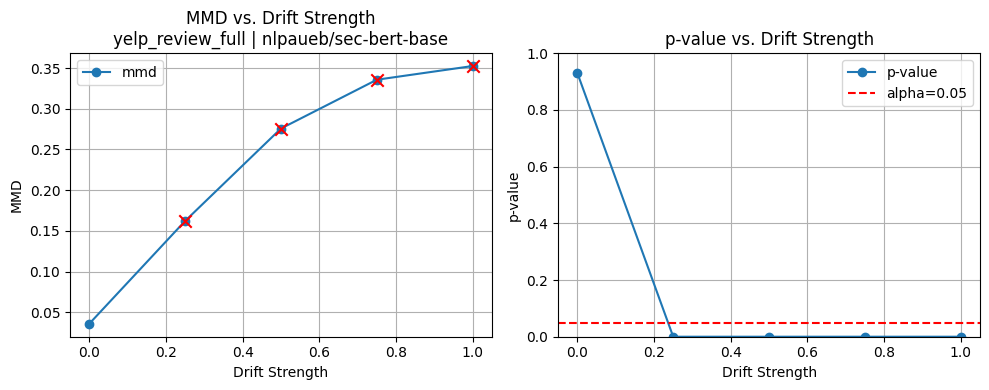

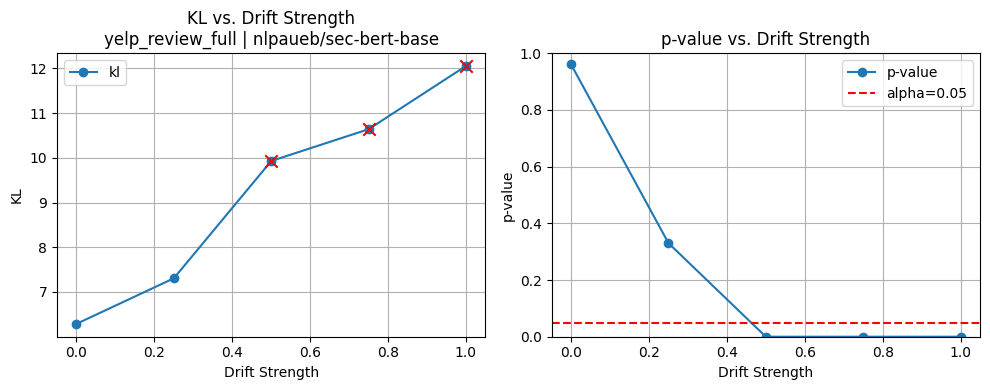

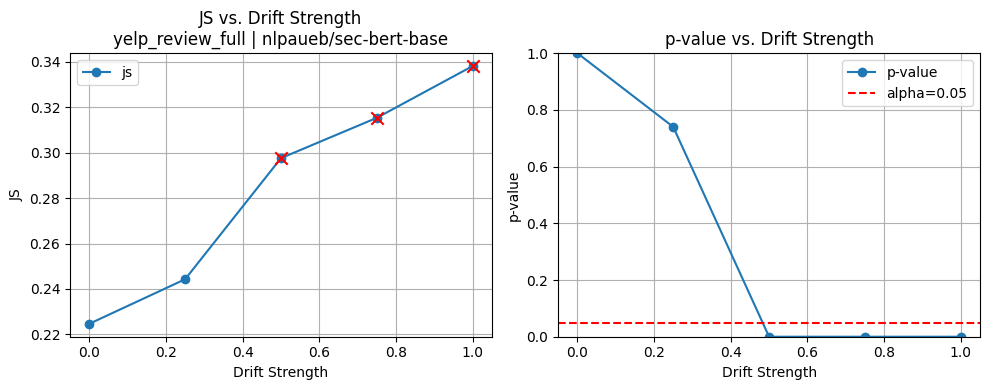

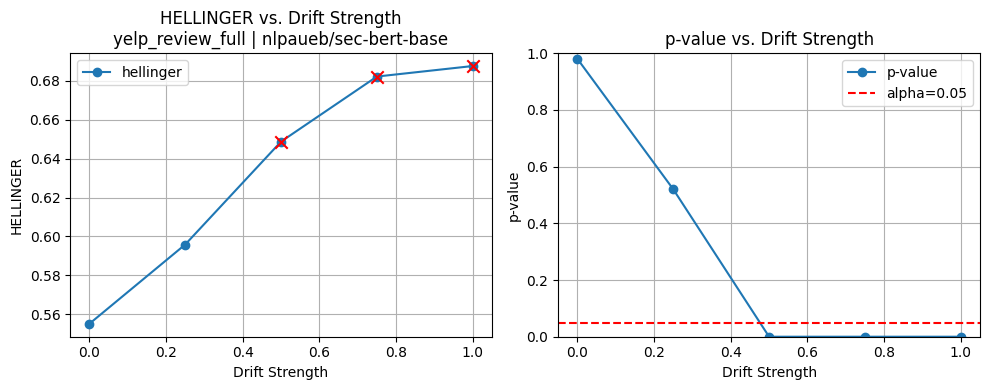

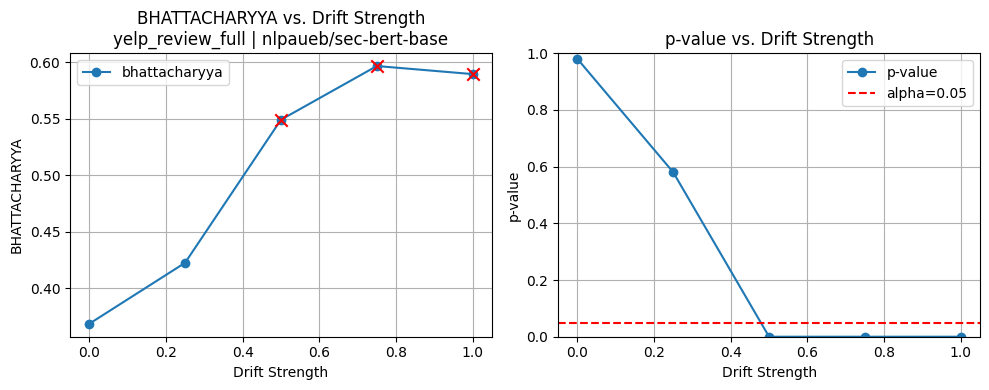

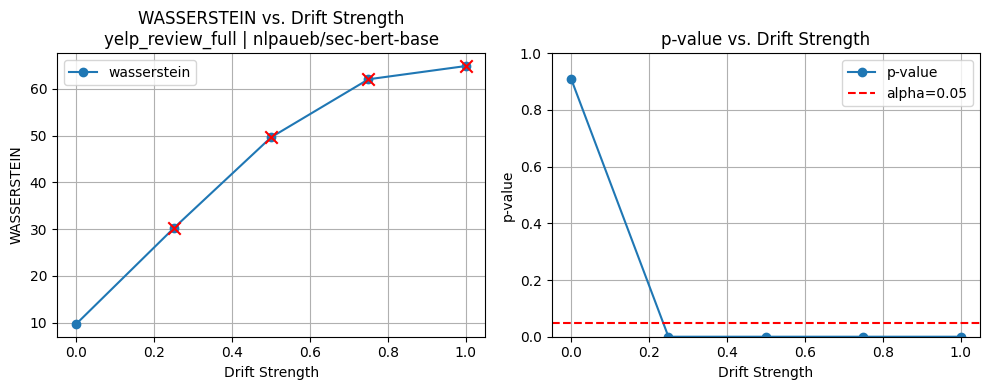

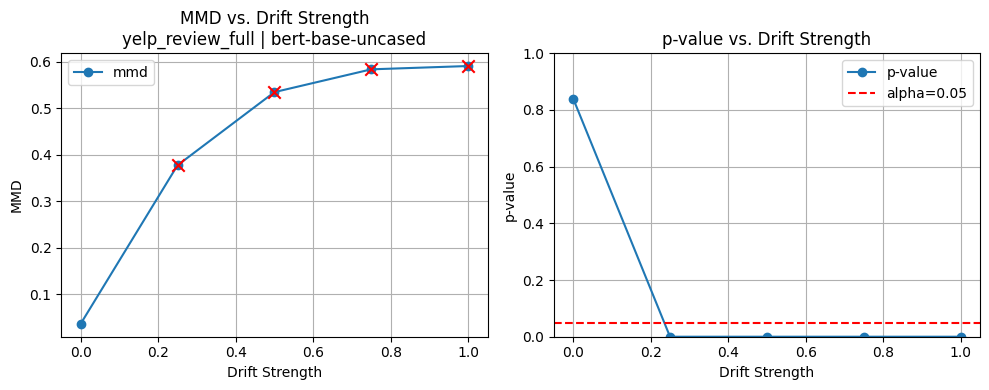

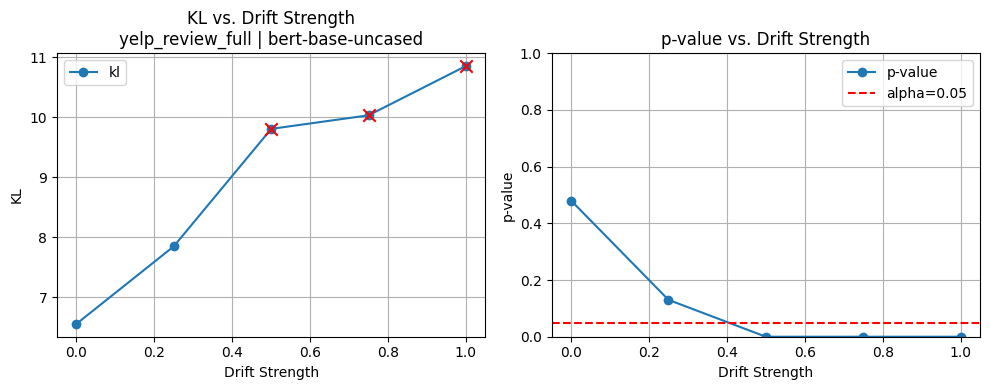

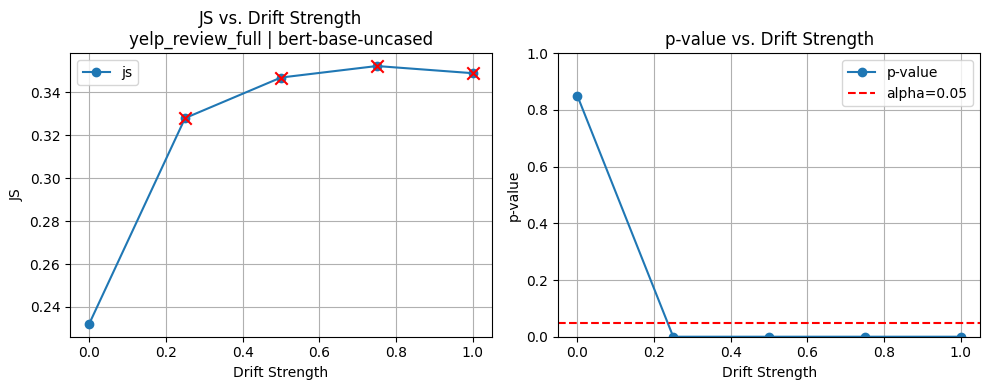

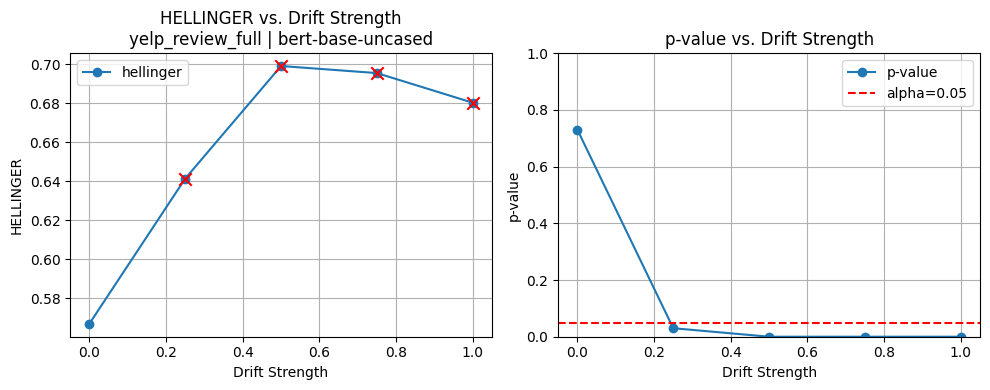

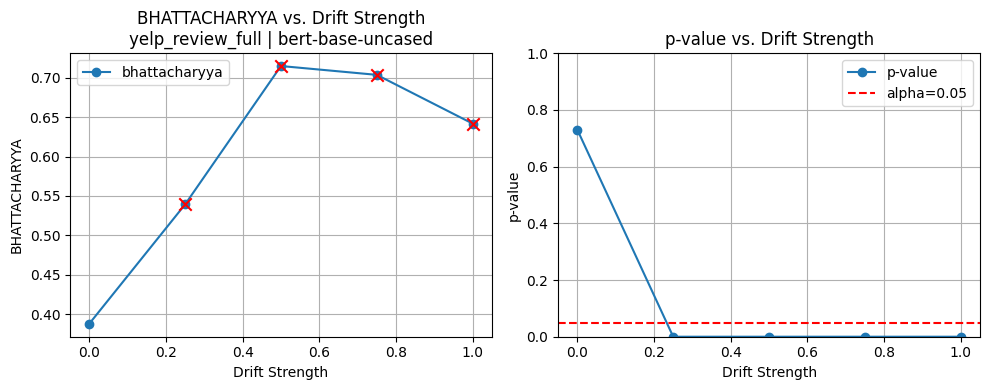

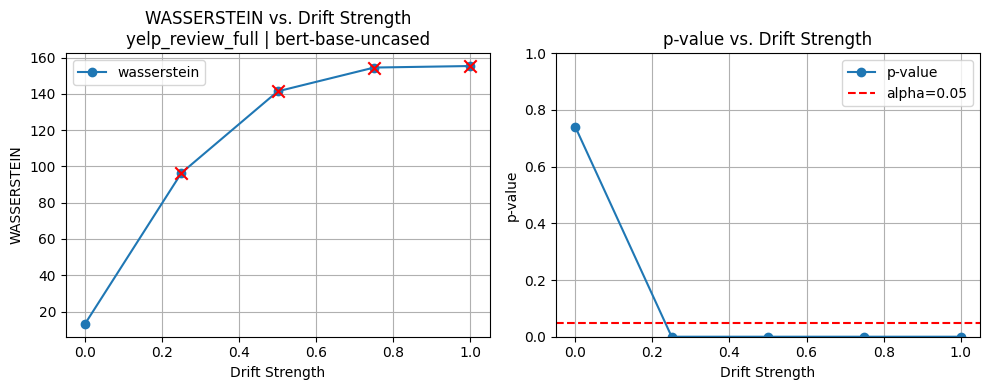

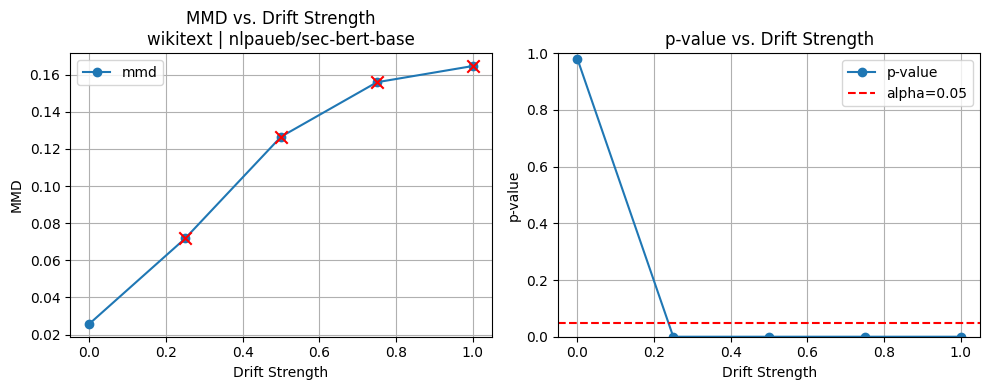

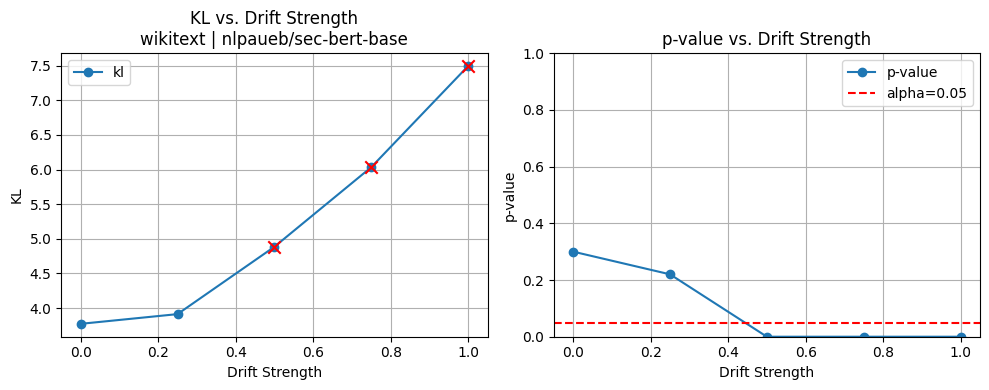

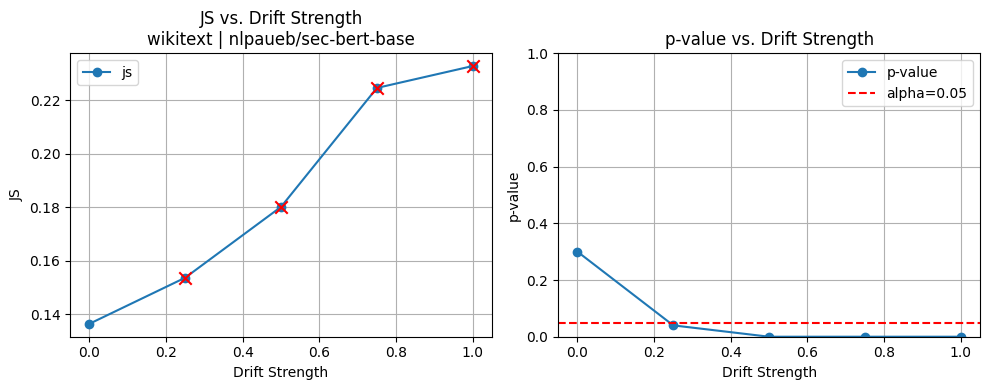

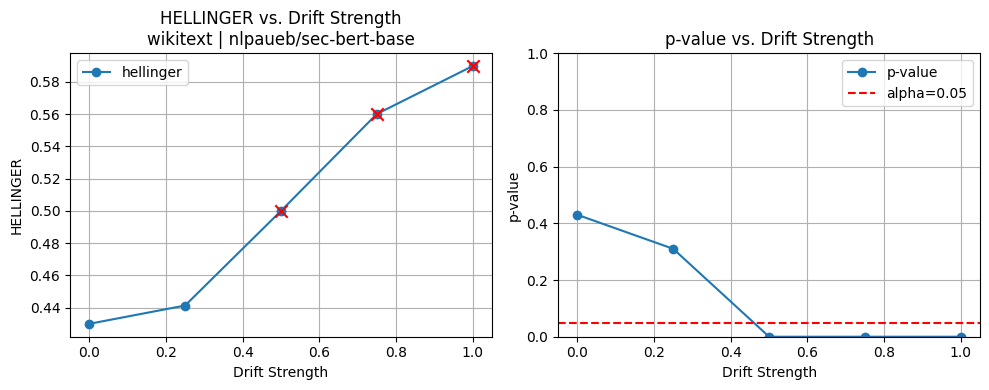

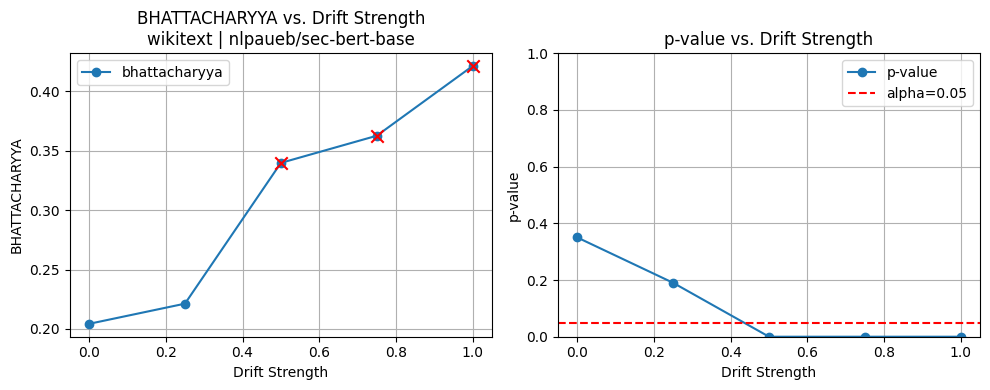

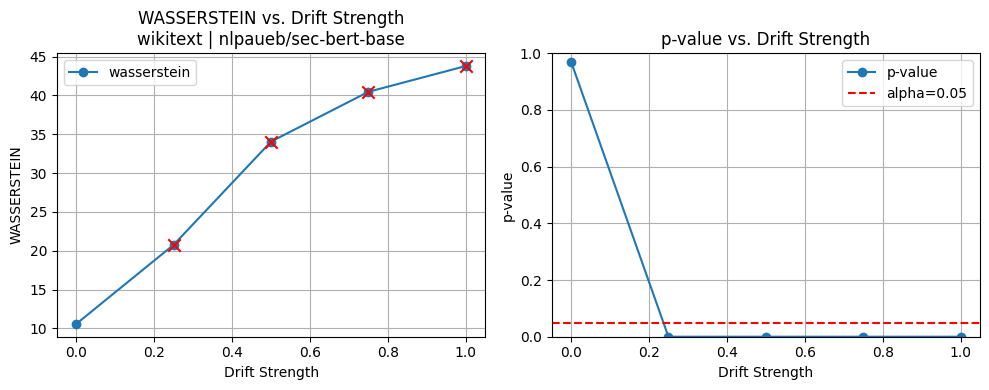

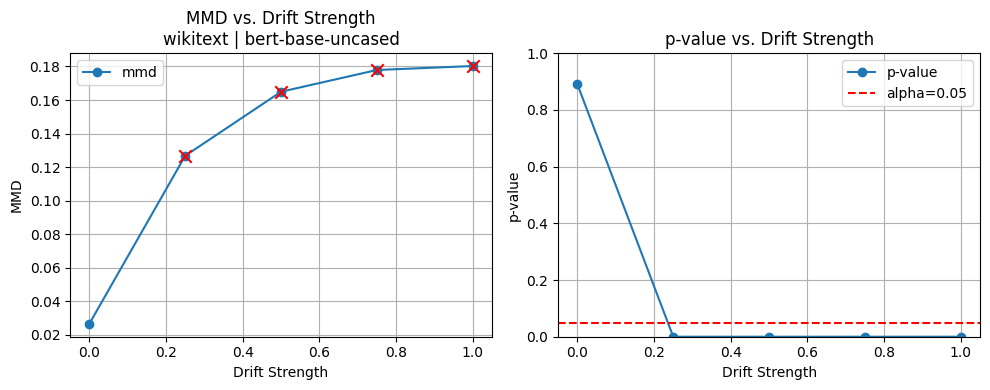

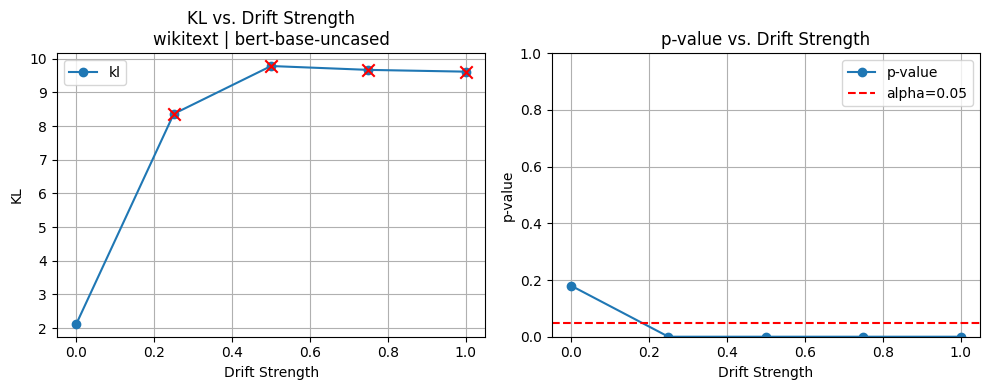

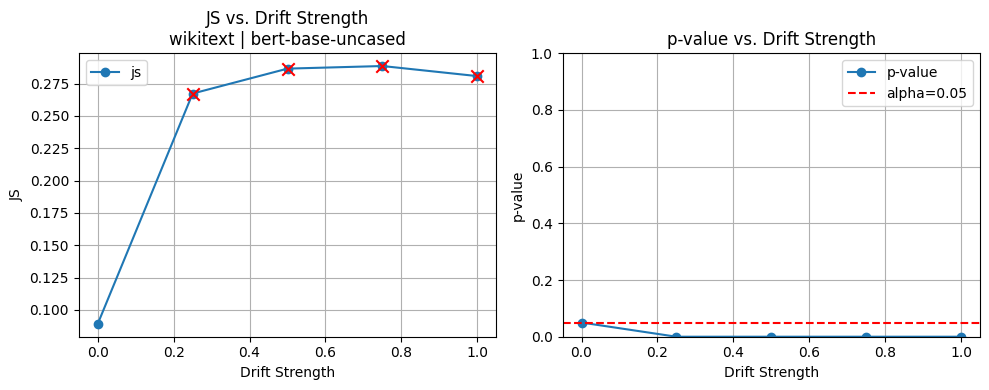

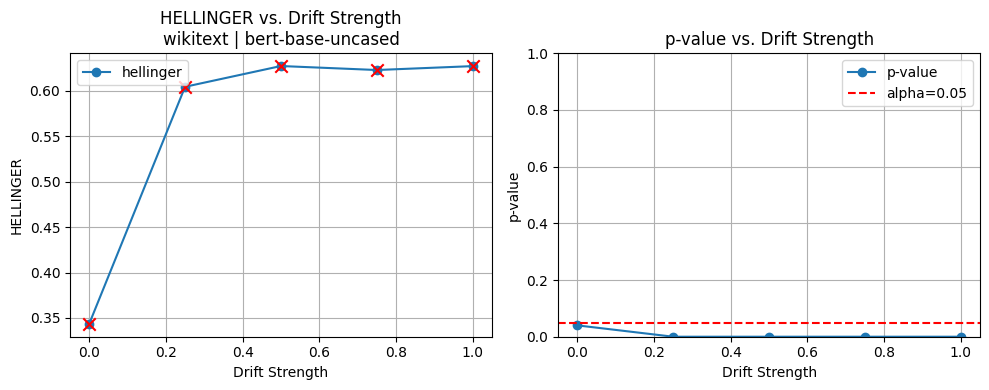

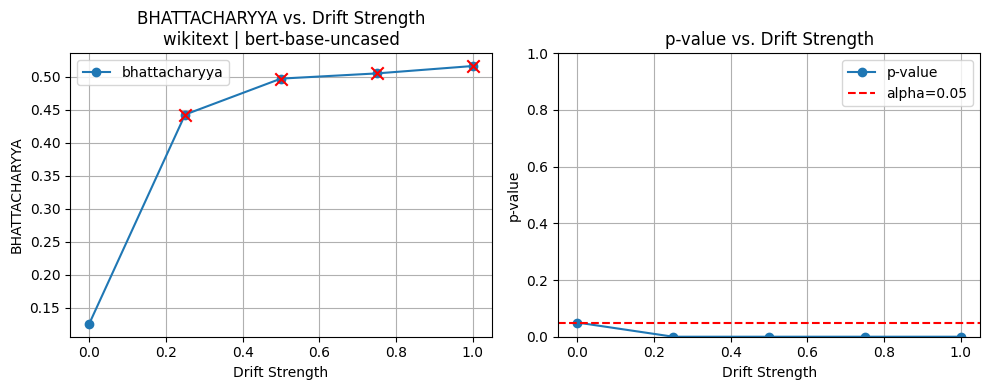

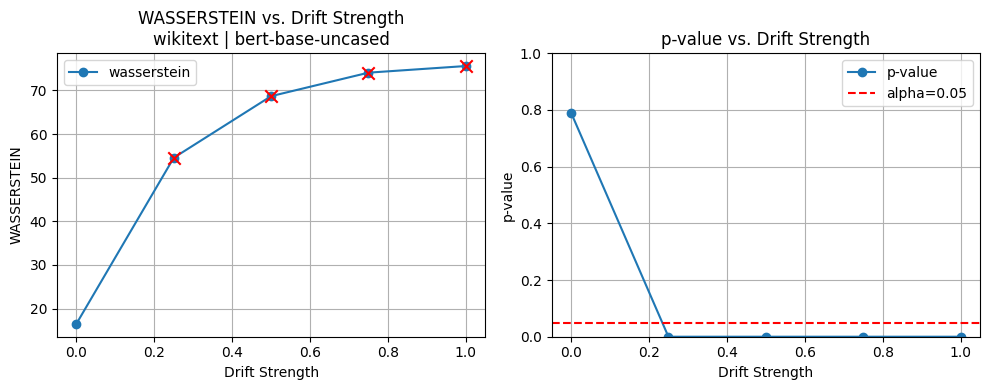

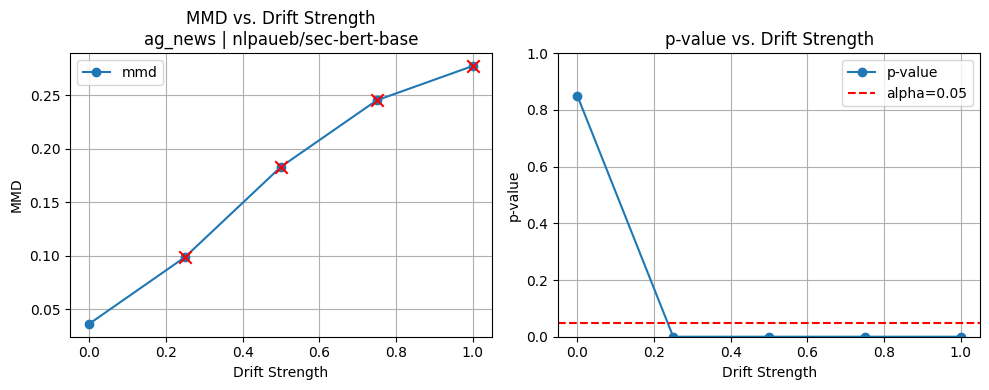

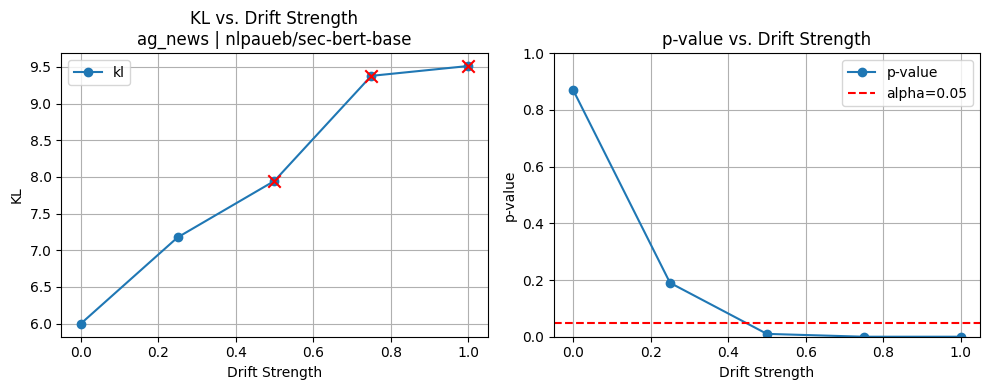

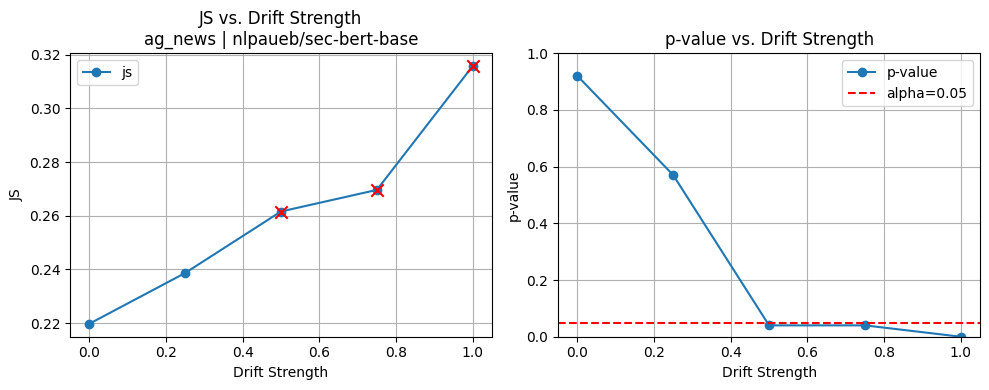

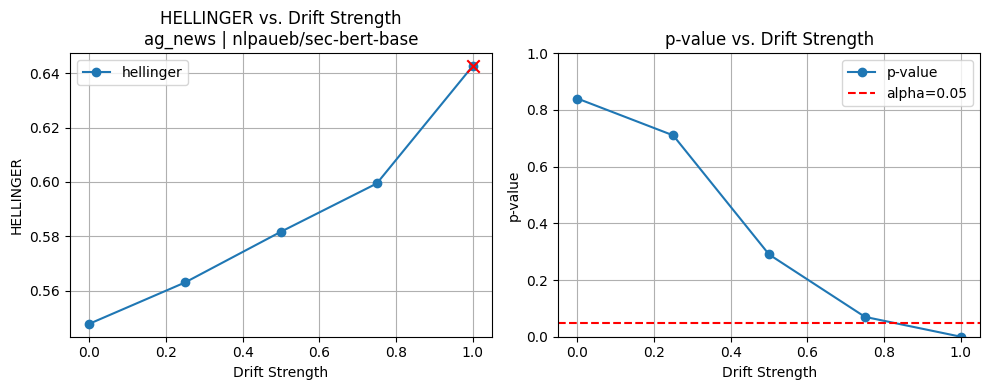

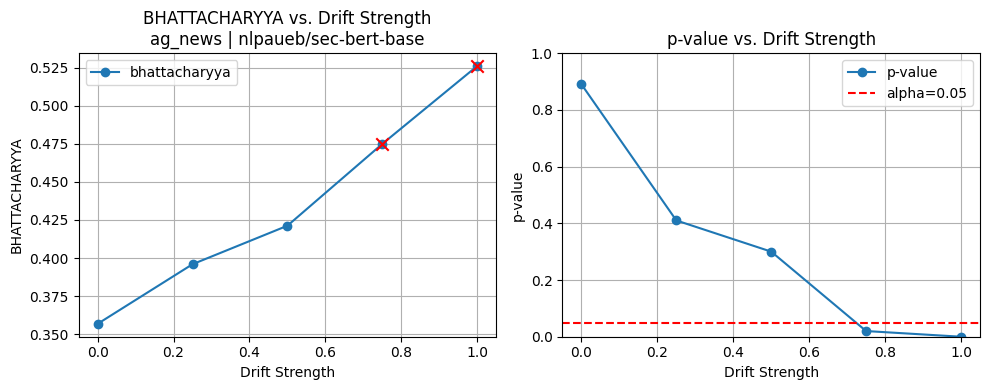

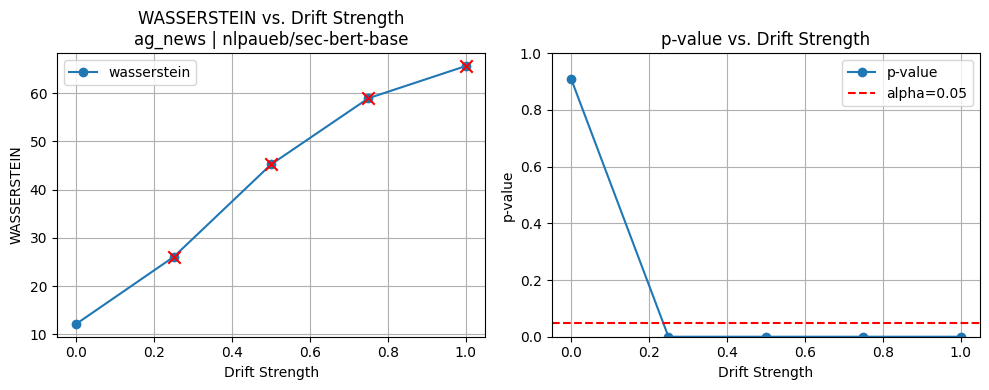

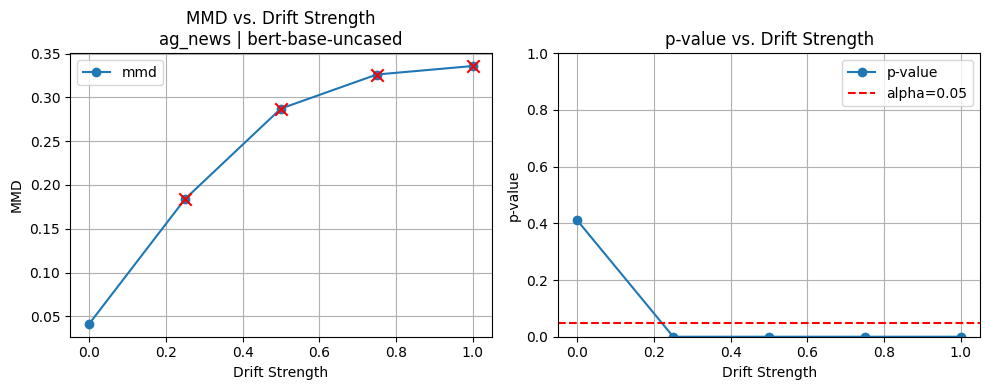

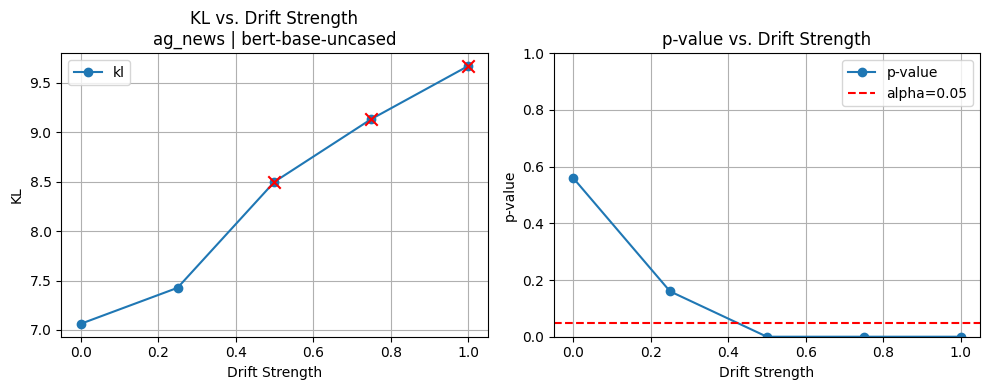

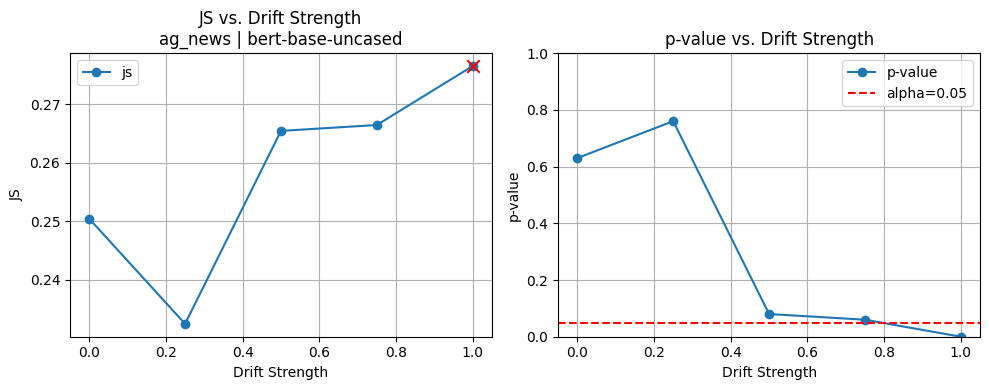

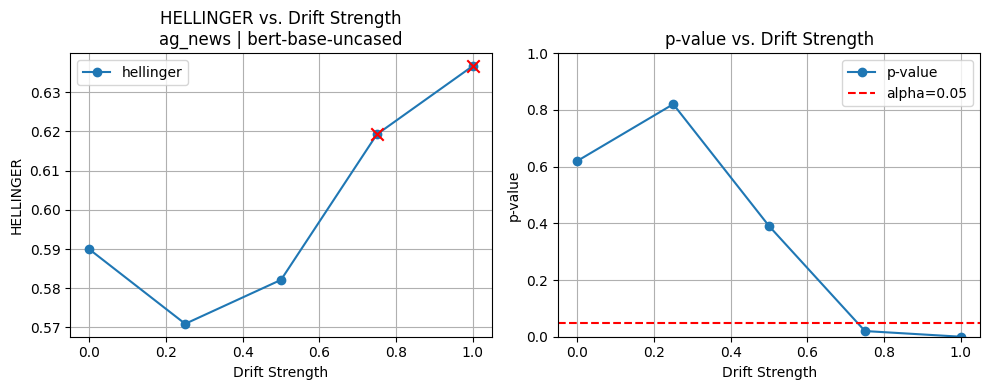

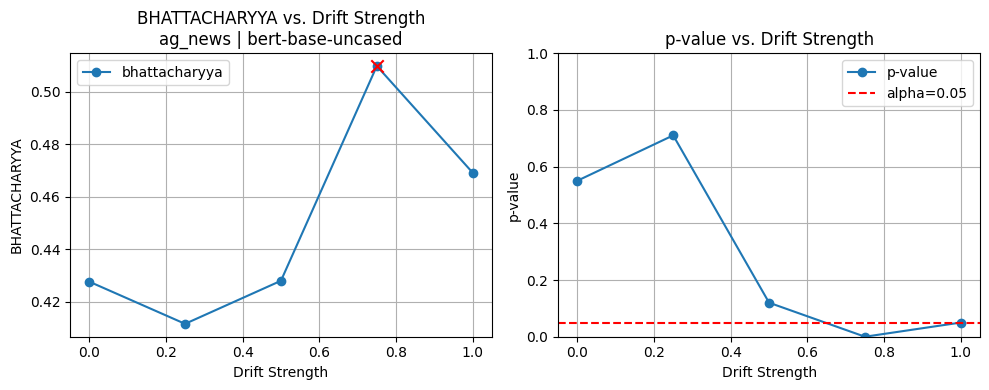

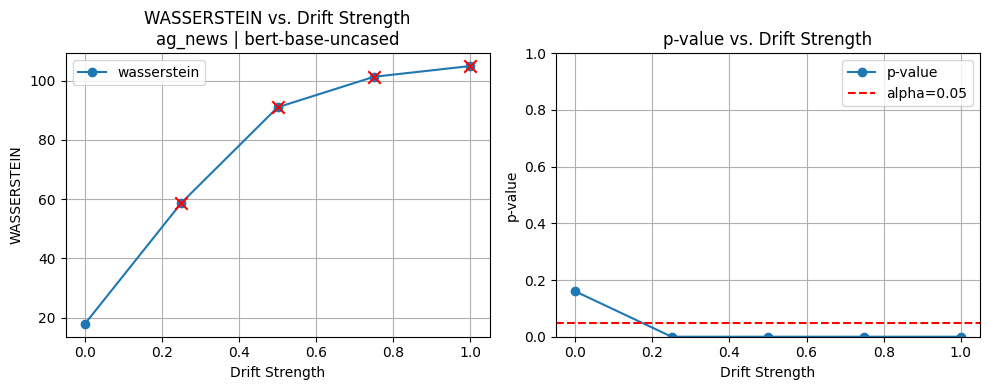

In [2]:
# -------------------------------------------------------------------
# (3) Plots (optional)
# -------------------------------------------------------------------
plot_results(all_results, alpha=args["alpha"])
# Example of permutation distribution for a single scenario:
# plot_permutation_distribution(all_results, "yelp_review_full", "nlpaueb/sec-bert-base", "js", 0.0)